# Experiment 4: Optimal Synthetic-to-Real Training Data Ratio

**Goal:** Determine the proportion of synthetic data that, when mixed with real data,
produces the highest detection accuracy after INT8 quantization for deployment on the Raspberry Pi 5.

**Model:** YOLO26n (best balance of accuracy and speed from Experiment 3)

**Ratios tested:** 0%, 10%, 20%, 30%, 40%, 50%, 60%, 70%, 80%, 90%, 100% synthetic

**Key design decisions:**
- Total training set size fixed at 1,795 images (matching Experiments 1-3)
- Stratified incremental sampling maintains 61%/39% day-night ratio
- Each ratio builds on the previous one (images at 10% are a subset of those at 20%)
- Validation set remains 100% real at all ratios
- All models evaluated on the same 660-image real test set

## Setup

In [1]:
!pip install ultralytics onnx onnxruntime-gpu

In [2]:
import os
import shutil
import random
import yaml
import numpy as np
from pathlib import Path

# ==============================================================
# PATHS — UPDATE THESE TO MATCH YOUR DIRECTORY STRUCTURE
# ==============================================================
BASE_DIR      = "/workspace/FYP_RESULTS/Final-Year-Project/datasets/my_data"
SYNTH_IMG_DIR = os.path.join(BASE_DIR, "synthetic/images")
SYNTH_LBL_DIR = os.path.join(BASE_DIR, "synthetic/labels")

# Output base for mixed datasets
MIX_BASE      = "/workspace/FYP_RESULTS/Final-Year-Project/datasets/mixed"
OUTPUT_DIR    = "/workspace/FYP_RESULTS/Final-Year-Project/runs/quantized_ratio"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# YOLO data config template (val and test always use real data)
YOLO_DATA_TEMPLATE = "/workspace/mydata_capped.yaml"

# Calibration images for INT8 quantization
with open("/workspace/train_capped.txt") as f:
    ALL_CALIB_IMAGES = [line.strip() for line in f if line.strip()][:100]
print(f"Calibration images: {len(ALL_CALIB_IMAGES)}")

TOTAL_TRAIN = 1795
RATIOS = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
SEEDS = [42, 123, 7]  # 3 runs per ratio for averaging
print(f"Ratios to test: {RATIOS}")
print(f"Seeds per ratio: {SEEDS}")
print(f"Total training images per ratio: {TOTAL_TRAIN}")
print(f"Total training runs: {len(RATIOS) * len(SEEDS)}")

Calibration images: 100
Ratios to test: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
Seeds per ratio: [42, 123, 7]
Total training images per ratio: 1795
Total training runs: 33


---
## 1. Create Mixed Training Sets

Stratified incremental sampling:
- Synthetic pool split into day (61%) and night (39%) subsets
- At each ratio, synthetic images are drawn proportionally from both subsets
- Each ratio is a superset of the previous one (incremental)
- Remaining slots filled with real images

In [3]:
def get_image_label_pairs(img_dir, lbl_dir):
    """Get sorted list of (image_path, label_path) pairs."""
    pairs = []
    for f in sorted(os.listdir(img_dir)):
        if not f.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        img_path = os.path.join(img_dir, f)
        lbl_path = os.path.join(lbl_dir, Path(f).stem + ".txt")
        pairs.append((img_path, lbl_path))
    return pairs

# Load REAL training images ONLY from train_capped.txt (avoids data leakage)
LABELS_DIR = os.path.join(BASE_DIR, "labels")
with open("/workspace/train_capped.txt") as f:
    train_image_paths = [line.strip() for line in f if line.strip()]

real_pairs = []
for img_path in train_image_paths:
    filename = os.path.basename(img_path)
    lbl_path = os.path.join(LABELS_DIR, Path(filename).stem + ".txt")
    real_pairs.append((img_path, lbl_path))

print(f"Real TRAINING images (from train_capped.txt): {len(real_pairs)}")

# Separate synthetic images into day and night
synth_pairs = get_image_label_pairs(SYNTH_IMG_DIR, SYNTH_LBL_DIR)
synth_day = [p for p in synth_pairs if "day" in Path(p[0]).stem.lower()]
synth_night = [p for p in synth_pairs if "night" in Path(p[0]).stem.lower()]

# If day/night can't be determined from filename, split proportionally
if not synth_day and not synth_night:
    print("WARNING: Cannot determine day/night from filenames. Using 61/39 split.")
    random.seed(42)
    random.shuffle(synth_pairs)
    split_idx = int(len(synth_pairs) * 0.61)
    synth_day = synth_pairs[:split_idx]
    synth_night = synth_pairs[split_idx:]

print(f"Synthetic day images available:     {len(synth_day)}")
print(f"Synthetic night images available:   {len(synth_night)}")
print(f"Total synthetic available:          {len(synth_day) + len(synth_night)}")
print(f"\nNo data leakage: real images sourced exclusively from training split.")

Real TRAINING images (from train_capped.txt): 1795
Synthetic day images available:     5223
Synthetic night images available:   4993
Total synthetic available:          10216

No data leakage: real images sourced exclusively from training split.


In [4]:
def create_mixed_dataset(ratio_pct, synth_day, synth_night, real_pairs, total=1795, seed=42):
    """Create a mixed dataset with stratified sampling using a given seed."""
    n_synth = int(total * ratio_pct / 100)
    n_real = total - n_synth

    # Shuffle with the given seed for this run
    day_copy = synth_day.copy()
    night_copy = synth_night.copy()
    real_copy = real_pairs.copy()
    random.seed(seed)
    random.shuffle(day_copy)
    random.shuffle(night_copy)
    random.shuffle(real_copy)

    # Stratified: 61% day, 39% night for synthetic
    n_synth_day = int(n_synth * 0.61)
    n_synth_night = n_synth - n_synth_day

    selected_synth = day_copy[:n_synth_day] + night_copy[:n_synth_night]
    selected_real = real_copy[:n_real]

    return selected_real + selected_synth

# Preview counts for each ratio (using first seed)
for ratio in RATIOS:
    pairs = create_mixed_dataset(ratio, synth_day, synth_night, real_pairs, TOTAL_TRAIN, seed=SEEDS[0])
    n_synth = int(TOTAL_TRAIN * ratio / 100)
    n_real = TOTAL_TRAIN - n_synth
    print(f"Ratio {ratio:3d}%: {n_real:4d} real + {n_synth:4d} synthetic = {len(pairs)} total")

Ratio   0%: 1795 real +    0 synthetic = 1795 total
Ratio  10%: 1616 real +  179 synthetic = 1795 total
Ratio  20%: 1436 real +  359 synthetic = 1795 total
Ratio  30%: 1257 real +  538 synthetic = 1795 total
Ratio  40%: 1077 real +  718 synthetic = 1795 total
Ratio  50%:  898 real +  897 synthetic = 1795 total
Ratio  60%:  718 real + 1077 synthetic = 1795 total
Ratio  70%:  539 real + 1256 synthetic = 1795 total
Ratio  80%:  359 real + 1436 synthetic = 1795 total
Ratio  90%:  180 real + 1615 synthetic = 1795 total
Ratio 100%:    0 real + 1795 synthetic = 1795 total


In [5]:
def setup_mixed_directory(ratio, seed, pairs):
    """Create a dataset directory with symlinks for a given ratio and seed."""
    mix_dir = os.path.join(MIX_BASE, f"ratio_{ratio}_seed_{seed}")
    img_dir = os.path.join(mix_dir, "images", "train")
    lbl_dir = os.path.join(mix_dir, "labels", "train")
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(lbl_dir, exist_ok=True)

    # Clean existing
    for f in os.listdir(img_dir):
        os.remove(os.path.join(img_dir, f))
    for f in os.listdir(lbl_dir):
        os.remove(os.path.join(lbl_dir, f))

    for img_path, lbl_path in pairs:
        img_name = os.path.basename(img_path)
        lbl_name = os.path.basename(lbl_path)
        os.symlink(img_path, os.path.join(img_dir, img_name))
        if os.path.exists(lbl_path):
            os.symlink(lbl_path, os.path.join(lbl_dir, lbl_name))

    # Create YAML config — val and test use the split .txt files (real data only)
    yaml_path = os.path.join(mix_dir, "data.yaml")
    config = {
        "path": mix_dir,
        "train": "images/train",
        "val": "/workspace/val_capped.txt",
        "test": "/workspace/test_capped.txt",
        "names": {0: "person"}
    }
    with open(yaml_path, "w") as f:
        yaml.dump(config, f)

    return yaml_path

# Set up all directories for each ratio × seed combination
yaml_paths = {}
for ratio in RATIOS:
    for seed in SEEDS:
        pairs = create_mixed_dataset(ratio, synth_day, synth_night, real_pairs, TOTAL_TRAIN, seed=seed)
        yaml_paths[(ratio, seed)] = setup_mixed_directory(ratio, seed, pairs)
    print(f"  Ratio {ratio:3d}%: created {len(SEEDS)} dataset variants")

print(f"\nTotal dataset directories: {len(yaml_paths)}")

  Ratio   0%: created 3 dataset variants
  Ratio  10%: created 3 dataset variants
  Ratio  20%: created 3 dataset variants
  Ratio  30%: created 3 dataset variants
  Ratio  40%: created 3 dataset variants
  Ratio  50%: created 3 dataset variants
  Ratio  60%: created 3 dataset variants
  Ratio  70%: created 3 dataset variants
  Ratio  80%: created 3 dataset variants
  Ratio  90%: created 3 dataset variants
  Ratio 100%: created 3 dataset variants

Total dataset directories: 33


---
## 2. Train, Export & Quantize at Each Ratio

For each ratio:
1. Train YOLO26n with shared config (epochs=40, lr0=2e-4, imgsz=832, freeze=0)
2. Export to FP32 ONNX
3. Quantize to INT8 (same pipeline as Experiment 3)
4. Evaluate INT8 model on real test set

In [6]:
import re
import onnx
from onnx import shape_inference
import onnxruntime as ort
from onnxruntime.quantization import (
    quantize_static, CalibrationDataReader, QuantFormat, QuantType
)
from PIL import Image


class ImageCalibrationReader(CalibrationDataReader):
    """Reads images and preprocesses them for ONNX model calibration."""
    def __init__(self, image_paths, input_name, imgsz=832):
        self.images = image_paths
        self.input_name = input_name
        self.imgsz = imgsz
        self.idx = 0

    def get_next(self):
        if self.idx >= len(self.images):
            return None
        img = Image.open(self.images[self.idx]).convert("RGB")
        img = img.resize((self.imgsz, self.imgsz))
        img_array = np.array(img, dtype=np.float32) / 255.0
        img_tensor = np.transpose(img_array, (2, 0, 1))[np.newaxis, ...]
        self.idx += 1
        return {self.input_name: img_tensor}


def quantize_model(fp32_path, int8_path, calib_images):
    """Quantize FP32 ONNX to INT8 using same pipeline as Experiment 3."""
    # Shape inference
    prep_path = fp32_path.replace(".onnx", "_prep.onnx")
    model_onnx = onnx.load(fp32_path)
    model_onnx = shape_inference.infer_shapes(model_onnx)
    onnx.save(model_onnx, prep_path)

    # Dynamically find detection head nodes (last 2 numbered layers)
    layer_nums = set()
    for node in model_onnx.graph.node:
        m = re.search(r'model\.(\d+)', node.name)
        if m:
            layer_nums.add(int(m.group(1)))
    sorted_layers = sorted(layer_nums)
    head_layer_nums = sorted_layers[-2:]
    head_tags = [f"model.{n}" for n in head_layer_nums]

    head_nodes = []
    for node in model_onnx.graph.node:
        if any(tag in node.name for tag in head_tags):
            head_nodes.append(node.name)
    print(f"  Excluding {len(head_nodes)} head nodes ({head_tags})")

    # Static quantization
    sess = ort.InferenceSession(prep_path)
    input_name = sess.get_inputs()[0].name
    reader = ImageCalibrationReader(calib_images, input_name, imgsz=832)

    quantize_static(
        prep_path, int8_path,
        calibration_data_reader=reader,
        quant_format=QuantFormat.QDQ,
        per_channel=True,
        weight_type=QuantType.QInt8,
        activation_type=QuantType.QUInt8,
        nodes_to_exclude=head_nodes,
    )

    os.remove(prep_path)
    fp32_sz = os.path.getsize(fp32_path) / (1024*1024)
    int8_sz = os.path.getsize(int8_path) / (1024*1024)
    print(f"  FP32: {fp32_sz:.1f} MB -> INT8: {int8_sz:.1f} MB")
    return int8_path

In [7]:
from ultralytics import YOLO

# Store per-run results: results_all[ratio][seed] = {metrics}
results_all = {}

for ratio in RATIOS:
    results_all[ratio] = {}
    for seed in SEEDS:
        print(f"\n{'='*70}")
        print(f"  RATIO: {ratio}% synthetic / {100-ratio}% real  |  SEED: {seed}")
        print(f"{'='*70}")

        data_yaml = yaml_paths[(ratio, seed)]
        run_name = f"yolo26n_ratio_{ratio}_seed_{seed}"

        # ----- Train -----
        print(f"\n[1/4] Training YOLO26n...")
        model = YOLO("yolo26n.pt")
        model.train(
            data=data_yaml,
            epochs=40,
            freeze=0,
            lr0=2e-4,
            imgsz=832,
            seed=seed,
            name=run_name
        )

        # ----- Export to FP32 ONNX -----
        print(f"\n[2/4] Exporting to FP32 ONNX...")
        best_pt = model.trainer.best
        export_model = YOLO(best_pt)
        fp32_path = export_model.export(format="onnx", imgsz=832)

        # Copy to output dir with clear name
        fp32_dst = os.path.join(OUTPUT_DIR, f"yolo26n_ratio_{ratio}_seed_{seed}_fp32.onnx")
        shutil.copy2(fp32_path, fp32_dst)

        # ----- Quantize to INT8 -----
        print(f"\n[3/4] Quantizing to INT8...")
        int8_dst = os.path.join(OUTPUT_DIR, f"yolo26n_ratio_{ratio}_seed_{seed}_int8.onnx")
        quantize_model(fp32_dst, int8_dst, ALL_CALIB_IMAGES)

        # ----- Evaluate INT8 on TEST set -----
        print(f"\n[4/4] Evaluating INT8 model on test set...")
        int8_model = YOLO(int8_dst, task="detect")
        metrics = int8_model.val(
            data=YOLO_DATA_TEMPLATE,
            split="test",
            imgsz=832,
            plots=False,
        )

        results_all[ratio][seed] = {
            "mAP50":     round(metrics.box.map50, 3),
            "mAP50-95":  round(metrics.box.map, 3),
            "Precision": round(metrics.box.mp, 3),
            "Recall":    round(metrics.box.mr, 3),
            "int8_path": int8_dst,
            "best_pt":   str(best_pt),
        }

        print(f"\n  -> Ratio {ratio}% seed {seed}: "
              f"test mAP@50={results_all[ratio][seed]['mAP50']:.3f}  "
              f"test mAP@50-95={results_all[ratio][seed]['mAP50-95']:.3f}  "
              f"P={results_all[ratio][seed]['Precision']:.3f}  "
              f"R={results_all[ratio][seed]['Recall']:.3f}")

print("\n\nAll ratios complete.")


  RATIO: 0% synthetic / 100% real  |  SEED: 42

[1/4] Training YOLO26n...
New https://pypi.org/project/ultralytics/8.4.30 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.24 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24081MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/workspace/FYP_RESULTS/Final-Year-Project/datasets/mixed/ratio_0_seed_42/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=832, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0002, 

/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 6.9s, saved as '/workspace/runs/detect/yolo26n_ratio_0_seed_425/weights/best.onnx' (9.5 MB)

Export complete (8.1s)
Results saved to /workspace/runs/detect/yolo26n_ratio_0_seed_425/weights
Predict:         yolo predict task=detect model=/workspace/runs/detect/yolo26n_ratio_0_seed_425/weights/best.onnx imgsz=832 
Validate:        yolo val task=detect model=/workspace/runs/detect/yolo26n_ratio_0_seed_425/weights/best.onnx imgsz=832 data=/workspace/FYP_RESULTS/Final-Year-Project/datasets/mixed/ratio_0_seed_42/data.yaml  
Visualize:       https://netron.app

[3/4] Quantizing to INT8...
  Excluding 129 head nodes (['model.22', 'model.23'])


  FP32: 9.5 MB -> INT8: 4.6 MB

[4/4] Evaluating INT8 model on test set...
Ultralytics 8.4.24 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24081MiB)
Loading /workspace/FYP_RESULTS/Final-Year-Project/runs/quantized_ratio/yolo26n_ratio_0_seed_42_int8.onnx for ONNX Runtime inference...
WARNING ⚠️ CUDA requested but CUDAExecutionProvider not available. Using CPU...
Using ONNX Runtime 1.24.4 with CPUExecutionProvider
Setting batch=1 input of shape (1, 3, 832, 832)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1242.3±767.4 MB/s, size: 229.7 KB)
val: Scanning /workspace/FYP_RESULTS/Final-Year-Project/datasets/my_data/labels... 660 images, 23 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 660/660 511.6it/s 1.3s0.2s
val: New cache created: /workspace/FYP_RESULTS/Final-Year-Project/datasets/my_data/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 660/660 9.6it/s 1:099<0.1ss
                   all       

/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


...

ONNX: export success ✅ 1.7s, saved as '/workspace/runs/detect/yolo26n_ratio_100_seed_1232/weights/best.onnx' (9.5 MB)

Export complete (2.2s)
Results saved to /workspace/runs/detect/yolo26n_ratio_100_seed_1232/weights
Predict:         yolo predict task=detect model=/workspace/runs/detect/yolo26n_ratio_100_seed_1232/weights/best.onnx imgsz=832 
Validate:        yolo val task=detect model=/workspace/runs/detect/yolo26n_ratio_100_seed_1232/weights/best.onnx imgsz=832 data=/workspace/FYP_RESULTS/Final-Year-Project/datasets/mixed/ratio_100_seed_123/data.yaml  
Visualize:       https://netron.app

[3/4] Quantizing to INT8...
  Excluding 129 head nodes (['model.22', 'model.23'])


  FP32: 9.5 MB -> INT8: 4.6 MB

[4/4] Evaluating INT8 model on test set...
Ultralytics 8.4.24 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24081MiB)
Loading /workspace/FYP_RESULTS/Final-Year-Project/runs/quantized_ratio/yolo26n_ratio_100_seed_123_int8.onnx for ONNX Runtime inference...
WARNING ⚠️ CUDA requested but CUDAExecutionProvider not available. Using CPU...
Using ONNX Runtime 1.24.4 with CPUExecutionProvider
Setting batch=1 input of shape (1, 3, 832, 832)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2417.2±337.2 MB/s, size: 251.8 KB)
val: Scanning /workspace/FYP_RESULTS/Final-Year-Project/datasets/my_data/labels... 660 images, 23 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 660/660 2.1Kit/s 0.3s0.0s
val: New cache created: /workspace/FYP_RESULTS/Final-Year-Project/datasets/my_data/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 660/660 14.0it/s 47.2s<0.1s
                   all     

/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: export success ✅ 2.1s, saved as '/workspace/runs/detect/yolo26n_ratio_100_seed_72/weights/best.onnx' (9.5 MB)

Export complete (2.6s)
Results saved to /workspace/runs/detect/yolo26n_ratio_100_seed_72/weights
Predict:         yolo predict task=detect model=/workspace/runs/detect/yolo26n_ratio_100_seed_72/weights/best.onnx imgsz=832 
Validate:        yolo val task=detect model=/workspace/runs/detect/yolo26n_ratio_100_seed_72/weights/best.onnx imgsz=832 data=/workspace/FYP_RESULTS/Final-Year-Project/datasets/mixed/ratio_100_seed_7/data.yaml  
Visualize:       https://netron.app

[3/4] Quantizing to INT8...
  Excluding 129 head nodes (['model.22', 'model.23'])


  FP32: 9.5 MB -> INT8: 4.6 MB

[4/4] Evaluating INT8 model on test set...
Ultralytics 8.4.24 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24081MiB)
Loading /workspace/FYP_RESULTS/Final-Year-Project/runs/quantized_ratio/yolo26n_ratio_100_seed_7_int8.onnx for ONNX Runtime inference...
WARNING ⚠️ CUDA requested but CUDAExecutionProvider not available. Using CPU...
Using ONNX Runtime 1.24.4 with CPUExecutionProvider
Setting batch=1 input of shape (1, 3, 832, 832)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2425.3±708.4 MB/s, size: 240.7 KB)
val: Scanning /workspace/FYP_RESULTS/Final-Year-Project/datasets/my_data/labels... 660 images, 23 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 660/660 2.1Kit/s 0.3s0.0s
val: New cache created: /workspace/FYP_RESULTS/Final-Year-Project/datasets/my_data/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 660/660 13.8it/s 47.7s<0.1s
                   all       

---
## Recovery Cell
Run this cell to rebuild results from saved INT8 models (if kernel was restarted after training).

In [7]:
import os
import numpy as np
from ultralytics import YOLO

RATIOS = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
SEEDS = [42, 123, 7]
OUTPUT_DIR = "/workspace/FYP_RESULTS/Final-Year-Project/runs/quantized_ratio"
YOLO_DATA_TEMPLATE = "/workspace/mydata_capped.yaml"

# Rebuild results_all by re-evaluating saved INT8 models on test set
results_all = {}
for ratio in RATIOS:
    results_all[ratio] = {}
    for seed in SEEDS:
        int8_path = os.path.join(OUTPUT_DIR, f"yolo26n_ratio_{ratio}_seed_{seed}_int8.onnx")
        if not os.path.exists(int8_path):
            print(f"  MISSING: {int8_path}")
            continue

        print(f"Evaluating ratio {ratio}% seed {seed}...")
        int8_model = YOLO(int8_path, task="detect")
        metrics = int8_model.val(
            data=YOLO_DATA_TEMPLATE,
            split="test",
            imgsz=832,
            plots=False,
        )
        results_all[ratio][seed] = {
            "mAP50":     round(metrics.box.map50, 3),
            "mAP50-95":  round(metrics.box.map, 3),
            "Precision": round(metrics.box.mp, 3),
            "Recall":    round(metrics.box.mr, 3),
            "int8_path": int8_path,
        }
        print(f"  -> {ratio}% seed {seed}: mAP@50={results_all[ratio][seed]['mAP50']:.3f} "
              f"mAP@50-95={results_all[ratio][seed]['mAP50-95']:.3f}")

print("\nRecovery complete. Now run cells 12, 13, 15.")

Evaluating ratio 0% seed 42...
Ultralytics 8.4.24 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24081MiB)
Loading /workspace/FYP_RESULTS/Final-Year-Project/runs/quantized_ratio/yolo26n_ratio_0_seed_42_int8.onnx for ONNX Runtime inference...
WARNING ⚠️ CUDA requested but CUDAExecutionProvider not available. Using CPU...
Using ONNX Runtime 1.24.4 with CPUExecutionProvider
Setting batch=1 input of shape (1, 3, 832, 832)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1863.2±764.7 MB/s, size: 193.6 KB)
val: Scanning /workspace/FYP_RESULTS/Final-Year-Project/datasets/my_data/labels.cache... 660 images, 23 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 660/660 71.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 660/660 12.0it/s 54.8s<0.1s
                   all        660        793      0.922      0.866       0.91       0.71
Speed: 9.1ms preprocess, 57.8ms inference, 0.0ms loss, 0.3ms postprocess per i

In [8]:
# Compute mean ± std across seeds for each ratio
avg_results = {}
for ratio in RATIOS:
    seeds_data = results_all[ratio]
    avg_results[ratio] = {}
    for metric in ["mAP50", "mAP50-95", "Precision", "Recall"]:
        vals = [seeds_data[s][metric] for s in SEEDS]
        avg_results[ratio][metric] = np.mean(vals)
        avg_results[ratio][f"{metric}_std"] = np.std(vals)

print("YOLO26n INT8 — Test Accuracy at Each Synthetic Ratio (mean ± std over 3 seeds)")
print("=" * 90)
print(f"{'Synth %':>8} {'Real %':>7} {'mAP@50':>14} {'mAP@50-95':>16} {'Precision':>14} {'Recall':>14}")
print("-" * 90)

for ratio in RATIOS:
    r = avg_results[ratio]
    print(f"{ratio:>7}% {100-ratio:>6}% "
          f"{r['mAP50']:>8.3f}±{r['mAP50_std']:.3f} "
          f"{r['mAP50-95']:>10.3f}±{r['mAP50-95_std']:.3f} "
          f"{r['Precision']:>8.3f}±{r['Precision_std']:.3f} "
          f"{r['Recall']:>8.3f}±{r['Recall_std']:.3f}")

YOLO26n INT8 — Test Accuracy at Each Synthetic Ratio (mean ± std over 3 seeds)
 Synth %  Real %         mAP@50        mAP@50-95      Precision         Recall
------------------------------------------------------------------------------------------
      0%    100%    0.904±0.009      0.689±0.015    0.926±0.010    0.851±0.014
     10%     90%    0.896±0.030      0.691±0.012    0.921±0.004    0.808±0.045
     20%     80%    0.855±0.011      0.663±0.009    0.879±0.015    0.768±0.012
     30%     70%    0.877±0.015      0.652±0.017    0.907±0.029    0.793±0.011
     40%     60%    0.872±0.030      0.660±0.010    0.897±0.017    0.799±0.040
     50%     50%    0.833±0.034      0.615±0.033    0.834±0.048    0.736±0.045
     60%     40%    0.864±0.041      0.643±0.035    0.886±0.016    0.788±0.051
     70%     30%    0.828±0.018      0.634±0.016    0.883±0.013    0.744±0.034
     80%     20%    0.755±0.064      0.573±0.050    0.880±0.035    0.639±0.056
     90%     10%    0.747±0.051      0.5

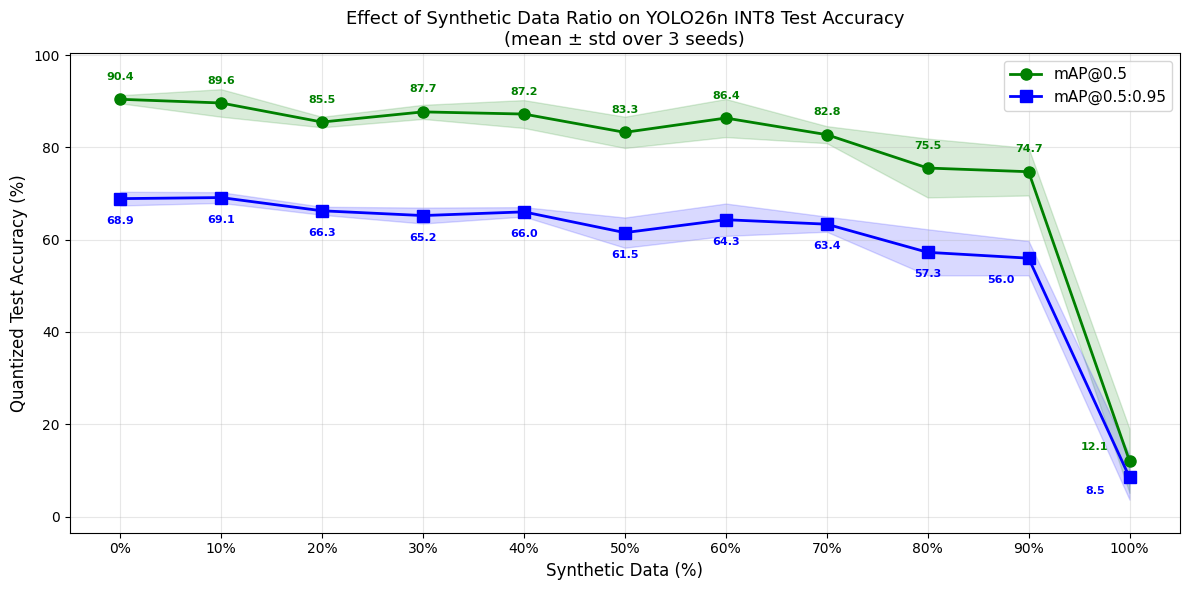

Plot saved.


In [9]:
import matplotlib.pyplot as plt

ratios_pct = [r for r in RATIOS]
map50_vals = [avg_results[r]["mAP50"] * 100 for r in RATIOS]
map50_std = [avg_results[r]["mAP50_std"] * 100 for r in RATIOS]
map95_vals = [avg_results[r]["mAP50-95"] * 100 for r in RATIOS]
map95_std = [avg_results[r]["mAP50-95_std"] * 100 for r in RATIOS]

fig, ax = plt.subplots(figsize=(12, 6))

# Plot lines
ax.plot(ratios_pct, map50_vals, 'go-', label='mAP@0.5', linewidth=2, markersize=8, zorder=3)
ax.plot(ratios_pct, map95_vals, 'bs-', label='mAP@0.5:0.95', linewidth=2, markersize=8, zorder=3)

# Shaded error bands instead of error bars
ax.fill_between(ratios_pct,
                [v - s for v, s in zip(map50_vals, map50_std)],
                [v + s for v, s in zip(map50_vals, map50_std)],
                color='green', alpha=0.15, zorder=1)
ax.fill_between(ratios_pct,
                [v - s for v, s in zip(map95_vals, map95_std)],
                [v + s for v, s in zip(map95_vals, map95_std)],
                color='blue', alpha=0.15, zorder=1)

# Annotate each point
for i, r in enumerate(ratios_pct):
    if r == 100:
        ax.annotate(f"{map50_vals[i]:.1f}", (r, map50_vals[i]), textcoords="offset points",
                    xytext=(-25, 8), ha='center', fontsize=8, fontweight='bold', color='green')
        ax.annotate(f"{map95_vals[i]:.1f}", (r, map95_vals[i]), textcoords="offset points",
                    xytext=(-25, -12), ha='center', fontsize=8, fontweight='bold', color='blue')
    elif r == 90:
        ax.annotate(f"{map50_vals[i]:.1f}", (r, map50_vals[i]), textcoords="offset points",
                    xytext=(0, 14), ha='center', fontsize=8, fontweight='bold', color='green')
        ax.annotate(f"{map95_vals[i]:.1f}", (r, map95_vals[i]), textcoords="offset points",
                    xytext=(-20, -18), ha='center', fontsize=8, fontweight='bold', color='blue')
    else:
        ax.annotate(f"{map50_vals[i]:.1f}", (r, map50_vals[i]), textcoords="offset points",
                    xytext=(0, 14), ha='center', fontsize=8, fontweight='bold', color='green')
        ax.annotate(f"{map95_vals[i]:.1f}", (r, map95_vals[i]), textcoords="offset points",
                    xytext=(0, -18), ha='center', fontsize=8, fontweight='bold', color='blue')

ax.set_xlabel('Synthetic Data (%)', fontsize=12)
ax.set_ylabel('Quantized Test Accuracy (%)', fontsize=12)
ax.set_title('Effect of Synthetic Data Ratio on YOLO26n INT8 Test Accuracy\n(mean ± std over 3 seeds)', fontsize=13)
ax.set_xticks(ratios_pct)
ax.set_xticklabels([f"{r}%" for r in ratios_pct])
ax.set_ylim(bottom=min(map95_vals) - 12, top=max(map50_vals) + 10)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "synthetic_ratio_test_accuracy.png"), dpi=150)
plt.show()
print("Plot saved.")

---
## 4. Identify Optimal Ratio

In [10]:
# =====================================================================
# Identify best ratio based on test mAP@50-95 (averaged over 3 seeds)
# =====================================================================
best_ratio = max(avg_results, key=lambda r: avg_results[r]["mAP50-95"])
best = avg_results[best_ratio]
baseline = avg_results[0]

print(f"Best ratio (by test mAP@50-95): {best_ratio}% synthetic / {100-best_ratio}% real")
print(f"  test mAP@0.50:      {best['mAP50']:.3f} ± {best['mAP50_std']:.3f}")
print(f"  test mAP@0.50:0.95: {best['mAP50-95']:.3f} ± {best['mAP50-95_std']:.3f}")
print(f"  test Precision:     {best['Precision']:.3f} ± {best['Precision_std']:.3f}")
print(f"  test Recall:        {best['Recall']:.3f} ± {best['Recall_std']:.3f}")

diff = best["mAP50-95"] - baseline["mAP50-95"]
print(f"\nImprovement over 0% synthetic: {diff:+.3f} mAP@50-95")
print(f"\nBaseline (0% synthetic) test mAP@50-95: {baseline['mAP50-95']:.3f} ± {baseline['mAP50-95_std']:.3f}")

Best ratio (by test mAP@50-95): 10% synthetic / 90% real
  test mAP@0.50:      0.896 ± 0.030
  test mAP@0.50:0.95: 0.691 ± 0.012
  test Precision:     0.921 ± 0.004
  test Recall:        0.808 ± 0.045

Improvement over 0% synthetic: +0.002 mAP@50-95

Baseline (0% synthetic) test mAP@50-95: 0.689 ± 0.015
